# FastWoe Conditional WOE

Author: https://www.github.com/xRiskLab

A standard WOE scorecard measures every feature against the whole book and adds the weights. That is exact only when the features are independent. When they are correlated, the signal they share is counted once per feature, and the scorecard becomes overconfident.

I. J. Good's chain rule gives the exact decomposition instead:

$$W(H : E_1 E_2) = W(H : E_1) + W(H : E_2 \mid E_1)$$

Each weight after the first is measured inside the population the earlier features already selected, so the weights still add and no independence is assumed. `FastWoe(conditional=True)` fits these weights, and `transform`, `predict_proba`, `predict_ci`, `get_mapping` and `get_iv_analysis` use them.

This notebook shows:

1. How marginal WOE double-counts correlated features
2. The conditional weights as a tree (`export_text`)
3. What the conditioning order changes, and what it does not
4. Conditional Information Value
5. Calibration against marginal WOE and logistic regression
6. Thin cells and fallbacks
7. Explaining a prediction with `WeightOfEvidence`

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

from fastwoe import FastWoe, WeightOfEvidence

pd.set_option("display.width", 140)

## 1. Two Correlated Features

We simulate 20,000 applicants. Delinquency drives utilisation, so the two share signal. Both also carry their own effect on default.

In [2]:
rng = np.random.default_rng(0)
n = 20_000

delinquent = rng.random(n) < 0.15
high_util = np.where(delinquent, rng.random(n) < 0.6, rng.random(n) < 0.2)
y = pd.Series(
    (rng.random(n) < expit(-2.5 + 1.5 * delinquent + 0.4 * high_util)).astype(int),
    name="default",
)
X = pd.DataFrame(
    {
        "delinquent": delinquent.astype(int).astype(str),
        "high_util": high_util.astype(int).astype(str),
    }
)

pd.crosstab([X["delinquent"], X["high_util"]], y, margins=True)

default                   0     1    All
delinquent high_util                    
0          0          12576  1060  13636
           1           3030   355   3385
1          0            886   334   1220
           1           1118   641   1759
All                   17610  2390  20000

Take an applicant who is delinquent **and** has high utilisation. The marginal scorecard adds two weights, each measured against the whole book:

In [3]:
applicant = pd.DataFrame({"delinquent": ["1"], "high_util": ["1"]})
cell = (X["delinquent"] == "1") & (X["high_util"] == "1")

marginal = FastWoe().fit(X, y)
conditional = FastWoe(conditional=True).fit(X, y)

pd.DataFrame(
    {
        "marginal": marginal.transform(applicant).iloc[0],
        "conditional": conditional.transform(applicant).iloc[0],
    }
)

,marginal,conditional
delinquent,1.276711,1.276711
high_util,0.570539,0.164196


In [4]:
print(f"Observed default rate in this cell: {y[cell].mean():.3f}  (n = {cell.sum():,})")
print(f"Marginal FastWoe:                   {marginal.predict_proba(applicant)[0, 1]:.3f}")
print(f"Conditional FastWoe:                {conditional.predict_proba(applicant)[0, 1]:.3f}")

Observed default rate in this cell: 0.364  (n = 1,759)
Marginal FastWoe:                   0.463
Conditional FastWoe:                0.364


The marginal scorecard says 46%; the cell's actual rate is 36%. Utilisation's weight of 0.571 is mostly delinquency counted a second time: given that the applicant is delinquent, high utilisation adds only 0.164. Conditional WOE reproduces the observed rate.

With no thin cells, the conditional fit is the maximum-likelihood estimate of P(default | features) for the saturated model: the chained weights add up to each cell's observed log-odds.

## 2. The Weights as a Tree

Conditional WOE along a fixed order is a decision tree: each level splits on the next feature, and each weight is the change in log-odds from a parent node to a child. `export_text()` prints it like `sklearn.tree.export_text`. The bars draw every 95% interval on one shared scale, with a zero line.

In [5]:
print(conditional.export_text())

Conditional WOE tree  ·  target: default  ·  event rate = share of rows with default = 1
Conditioning order: delinquent → high_util  ·  prior log-odds -1.997

                            W  95% interval           n  event rate  -0.46  0                 +1.35
root                                             20,000       11.9%
├── delinquent = 0     -0.403  [-0.458, -0.349]  17,021        8.3%  ─●─    ┊
│   ├── high_util = 0  -0.073  [-0.136, -0.010]  13,636        7.8%       ─●─
│   └── high_util = 1  +0.256  [+0.146, +0.366]   3,385       10.5%         ┊  ─●──
└── delinquent = 1     +1.277  [+1.200, +1.353]   2,979       32.7%         ┊                   ─●─
    ├── high_util = 0  -0.255  [-0.381, -0.129]   1,220       27.4%   ──●── ┊
    └── high_util = 1  +0.164  [+0.067, +0.261]   1,759       36.4%         ┊──●──


A leaf's log-odds are the prior plus the weights on its path: -1.997 + 1.277 + 0.164 = -0.556, which is 36.4%. The weight of `high_util = 1` differs by branch (+0.256 vs +0.164): that is the interaction a marginal scorecard cannot represent.

## 3. What the Order Changes

The order defaults to the column order of `X`; `conditional_order=` overrides it.

In [6]:
rows = {}
for order in (["delinquent", "high_util"], ["high_util", "delinquent"]):
    model = FastWoe(conditional=True, conditional_order=order).fit(X, y)
    weights = model.transform(applicant).iloc[0]
    rows[" -> ".join(order)] = {
        **weights.to_dict(),
        "sum": weights.sum(),
        "P(default)": model.predict_proba(applicant)[0, 1],
    }
pd.DataFrame(rows).T.round(3)

,delinquent,high_util,sum,P(default)
delinquent -> high_util,1.277,0.164,1.441,0.364
high_util -> delinquent,0.870,0.571,1.441,0.364


- **The score does not depend on the order.** Both orders end in the same cell, and the weights always add up to that cell's log-odds.
- **The attribution does.** Whichever feature comes first claims the shared signal. If the weights are used for explanations (reason codes, points per feature), choose the order deliberately, for example cause before symptom, and document it.

With three or more features, thin cells that fall back to marginal weights (section 6) can land in different places for different orders, and then the score can differ too.

## 4. Conditional Information Value

IV follows the same chain rule. `get_iv_analysis()` keeps `iv` as the marginal IV and, with `conditional=True`, adds `iv_conditional`: the IV a feature adds given the features before it, with its standard error, confidence interval and a chi-square p-value.

In [7]:
conditional.get_iv_analysis()[
    ["feature", "iv", "iv_se", "iv_pvalue", "conditioned_on", "iv_conditional",
     "iv_conditional_se", "iv_conditional_pvalue"]
]

,feature,iv,iv_se,iv_pvalue,conditioned_on,iv_conditional,iv_conditional_se,iv_conditional_pvalue
0,delinquent,0.4942,0.0311,0.0,-,0.4942,0.0311,0.0
1,high_util,0.1524,0.0171,0.0,delinquent,0.0245,0.0069,0.0


In [8]:
joint = X.agg("|".join, axis=1).to_frame("joint")
joint_iv = FastWoe().fit(joint, y).feature_stats_["joint"]["iv"]
iv = conditional.get_iv_analysis()
print(f"Sum of marginal IVs:     {iv['iv'].sum():.4f}")
print(f"Sum of conditional IVs:  {iv['iv_conditional'].sum():.4f}")
print(f"Joint IV of both:        {joint_iv:.4f}")

Sum of marginal IVs:     0.6466
Sum of conditional IVs:  0.5187
Joint IV of both:        0.5187


Marginal IV double-counts just as marginal WOE does. Conditional IVs add up to the joint IV. `high_util` has IV 0.15 on its own but adds 0.02 given delinquency: much less, though still significant here, because the data do carry a utilisation effect beyond delinquency.

- **Marginal IV**: how predictive is a feature on its own? Use it for screening.
- **Conditional IV**: how much does it add given the features before it? Use it to decide what to keep from a correlated set.

## 5. Calibration

A larger example: four features with shared signal and a delinquent x high-utilisation interaction, 80,000 rows split in half. We compare four models on the holdout:

- **Marginal FastWoe** (sum of WOE, naive Bayes)
- **Conditional FastWoe**
- **Logistic regression on marginal WOE** (the classic scorecard)
- **Logistic regression on conditional WOE**

In [9]:
rng = np.random.default_rng(42)
n = 80_000
d = rng.random(n) < 0.15
u = np.where(d, rng.random(n) < 0.6, rng.random(n) < 0.2)
q = np.minimum(rng.poisson(np.where(d, 2.0, 0.6)), 3)
r = rng.choice(["north", "south", "west"], n, p=[0.5, 0.3, 0.2])
logit = (
    -3.0 + 1.3 * d + 0.5 * u + 0.25 * q + 0.6 * (d & u)
    + np.select([r == "south", r == "west"], [0.3, -0.2], 0.0)
)
y4 = pd.Series((rng.random(n) < expit(logit)).astype(int), name="default")
X4 = pd.DataFrame(
    {"delinquent": d.astype(int).astype(str), "high_util": u.astype(int).astype(str),
     "inquiries": q.astype(str), "region": r}
)
X_tr, X_te, y_tr, y_te = train_test_split(X4, y4, test_size=0.5, random_state=0, stratify=y4)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # a few thin cells fall back; see section 6
    marg4 = FastWoe().fit(X_tr, y_tr)
    cond4 = FastWoe(conditional=True).fit(X_tr, y_tr)


def lr_on(model):
    return LogisticRegression(penalty=None, max_iter=1000).fit(model.transform(X_tr), y_tr)


lr_marg, lr_cond = lr_on(marg4), lr_on(cond4)
models = {
    "FastWoe (marginal)": marg4.predict_proba(X_te)[:, 1],
    "FastWoe (conditional)": cond4.predict_proba(X_te)[:, 1],
    "LR on marginal WOE": lr_marg.predict_proba(marg4.transform(X_te))[:, 1],
    "LR on conditional WOE": lr_cond.predict_proba(cond4.transform(X_te))[:, 1],
}


def reliability(p, y, bins=10):
    df = pd.DataFrame({"p": p, "y": np.asarray(y)})
    df["bin"] = pd.qcut(df["p"].rank(method="first"), bins, labels=False)
    g = df.groupby("bin").agg(pred=("p", "mean"), obs=("y", "mean"), n=("y", "size"))
    return g, float((g["n"] * (g["pred"] - g["obs"]).abs()).sum() / g["n"].sum())


curves, rows = {}, []
for name, p in models.items():
    curves[name], ece = reliability(p, y_te)
    rows.append({"model": name, "log_loss": log_loss(y_te, p), "brier": brier_score_loss(y_te, p),
                 "ECE": ece, "AUC": roc_auc_score(y_te, p), "mean_pred": p.mean()})
print(f"Observed default rate: {y_te.mean():.4f}")
pd.DataFrame(rows).set_index("model").round(4)

Observed default rate: 0.1115


,log_loss,brier,ECE,AUC,mean_pred
model,,,,,
FastWoe (marginal),0.3200,0.0916,0.0518,0.7450,0.1298
FastWoe (conditional),0.2949,0.0835,0.0053,0.7462,0.1117
LR on marginal WOE,0.2954,0.0837,0.0092,0.7460,0.1117
LR on conditional WOE,0.2949,0.0835,0.0052,0.7462,0.1117


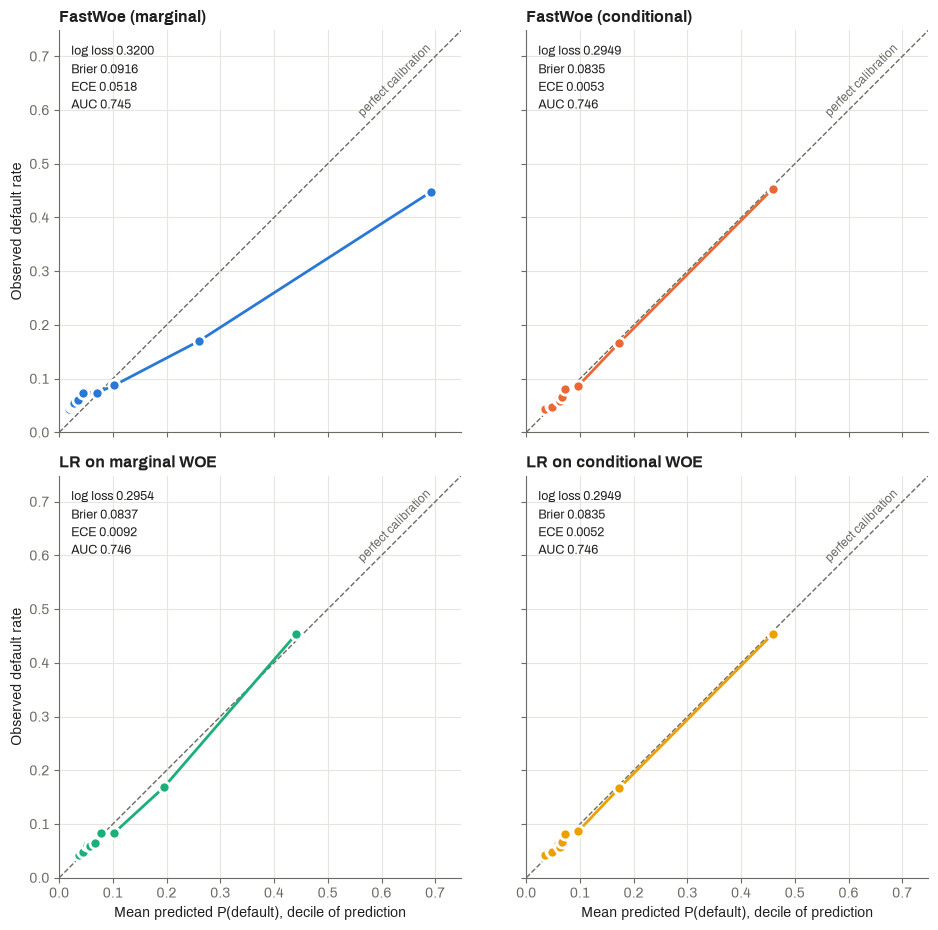

In [10]:
# Archivo if installed, otherwise matplotlib's default sans-serif
for path in font_manager.findSystemFonts():
    if "Archivo-" in path and "Narrow" not in path and "Black" not in path:
        font_manager.fontManager.addfont(path)
INK, MUTED, GRID = "#1f1f1e", "#6b6a63", "#e6e5df"
plt.rcParams.update({
    "font.family": ["Archivo", "DejaVu Sans"], "font.size": 10,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})
colors = dict(zip(models, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
lim = max(max(c["pred"].max(), c["obs"].max()) for c in curves.values()) * 1.08

fig, axes = plt.subplots(2, 2, figsize=(10, 9.4), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
metrics = pd.DataFrame(rows).set_index("model")
for ax, (name, curve) in zip(axes.ravel(), curves.items()):
    ax.set_facecolor("white")
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.plot([0, lim], [0, lim], color=MUTED, linewidth=1, linestyle="--")
    ax.text(lim * 0.93, lim * 0.95, "perfect calibration", rotation=45, rotation_mode="anchor",
            ha="right", va="bottom", fontsize=8.5, color=MUTED, transform_rotates_text=True)
    ax.plot(curve["pred"], curve["obs"], color=colors[name], linewidth=2, marker="o",
            markersize=8, markeredgecolor="white", markeredgewidth=2, zorder=3)
    m = metrics.loc[name]
    ax.set_title(name, loc="left", fontsize=11.5, color=INK, fontweight="bold")
    ax.text(0.03, 0.97, f"log loss {m.log_loss:.4f}\nBrier {m.brier:.4f}\nECE {m.ECE:.4f}\nAUC {m.AUC:.3f}",
            transform=ax.transAxes, va="top", fontsize=9, color=INK, linespacing=1.5)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")
for ax in axes[1]:
    ax.set_xlabel("Mean predicted P(default), decile of prediction")
for ax in axes[:, 0]:
    ax.set_ylabel("Observed default rate")
fig.tight_layout()
plt.show()

In [11]:
pd.DataFrame(
    {"LR on marginal WOE": lr_marg.coef_[0], "LR on conditional WOE": lr_cond.coef_[0]},
    index=X4.columns,
).round(3)

,LR on marginal WOE,LR on conditional WOE
delinquent,0.727,0.999
high_util,0.579,1.003
inquiries,0.400,1.002
region,1.165,1.000


- **Marginal FastWoe ranks well but is overconfident**: the same AUC as the others, but its top decile predicts far more defaults than occur. That is the double counting.
- **Logistic regression on marginal WOE** corrects most of it with coefficients below 1 on the correlated features, but it cannot represent the interaction.
- **Conditional FastWoe is calibrated by construction.**
- **Logistic regression on conditional WOE learns coefficients of 1**: the conditional fit is already the maximum-likelihood fit, so a regression on top has nothing to correct. It becomes useful again only when many cells fall back (section 6), as a recalibration step.

The setup favours conditional WOE: four features, 48 cells, 40,000 training rows. With many features the cells get thin; logistic regression on marginal WOE is the more robust default for a whole scorecard, and conditional WOE the tool for a short list of features you know are correlated.

## 6. Thin Cells and Fallbacks

Conditioning cells multiply with each feature. A cell with fewer than `conditional_min_count` (default 30) bads or goods has too little data for its own weight, so it falls back to the feature's marginal weight. Every fallback is recorded in `conditional_fallbacks_` and marked `[fallback]` with a hollow point in `export_text()`.

In [12]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    thin = FastWoe(conditional=True, conditional_min_count=400).fit(X, y)
print(caught[0].message)
print()
print(thin.export_text())

2 conditioning cells had fewer than 400 of a class and fell back to the marginal weight. See conditional_fallbacks_; consider fewer features, coarser bins, or a lower conditional_min_count.

Conditional WOE tree  ·  target: default  ·  event rate = share of rows with default = 1
Conditioning order: delinquent → high_util  ·  prior log-odds -1.997

                            W  95% interval           n  event rate  -0.46  0                 +1.35
root                                             20,000       11.9%
├── delinquent = 0     -0.403  [-0.458, -0.349]  17,021        8.3%  ─●─    ┊
│   ├── high_util = 0  -0.073  [-0.136, -0.010]  13,636        7.8%       ─●─
│   └── high_util = 1  +0.571  [+0.501, +0.640]   3,385       10.5%         ┊       ─○──             [fallback]
└── delinquent = 1     +1.277  [+1.200, +1.353]   2,979       32.7%         ┊                   ─●─
    ├── high_util = 0  -0.271  [-0.326, -0.215]   1,220       27.4%    ─○─  ┊                        [fallback]
  

In [13]:
pd.DataFrame(thin.conditional_fallbacks_)

,feature,given,category,bad,good,bad_in_cell,good_in_cell,reason
0,high_util,{'delinquent': '0'},1,355,3030,1415,15606,thin cell
1,high_util,{'delinquent': '1'},0,334,886,975,2004,thin cell


A fallen-back cell reintroduces a marginal weight, and with it some double counting: the model becomes a mix of the conditional fit and naive Bayes. Keep the feature list short, coarsen bins, or lower `conditional_min_count` (at the cost of noisier weights, visible as wider intervals).

## 7. Explaining a Prediction

`WeightOfEvidence` explains a conditional model through its ordinary API. The contributions are the conditional weights, and the interval is the conditional one.

In [14]:
explainer = WeightOfEvidence(conditional, X, y)
explanation = explainer.explain_ci(applicant, return_dict=True)
{
    "feature_contributions": explanation["feature_contributions"],
    "total_woe": explanation["total_woe"],
    "predicted_proba": explanation["predicted_proba"],
    "P(default) 95% CI": (
        explanation["ci_conservative"]["predicted_proba_ci"],
        explanation["ci_optimistic"]["predicted_proba_ci"],
    ),
}

{'feature_contributions': {'delinquent': 1.2767105653577873,
  'high_util': 0.16419579441253399},
 'total_woe': 1.4409063597703213,
 'predicted_proba': {'Negative': 0.63559, 'Positive': 0.36441},
 'P(default) 95% CI': (0.34223055174990447, 0.38718403591997697)}

Utilisation contributes 0.164, not 0.571: the explanation no longer credits it with evidence delinquency already provided.

## Summary

- `FastWoe(conditional=True)` measures each feature's weight within the groups the earlier features define, so correlated features are not double-counted.
- With no fallbacks it is the maximum-likelihood fit of the saturated model: calibrated by construction, and a logistic regression on top learns coefficients of 1.
- The order changes how evidence is attributed across features, not the score (with three or more features, fallbacks can change the score too).
- `export_text()` shows the tree of weights; `get_iv_analysis()` adds conditional IV, which sums to the joint IV.
- Best for a short list of correlated features. For a whole scorecard, logistic regression on marginal WOE remains the robust default.